# Jurnal Modul 3 #

# Import Library # 
numpy digunakan untuk operasi matriks dan array.
matplotlib.pyplot digunakan untuk menampilkan citra.
cv2 (OpenCV) digunakan untuk membaca dan memproses citra.
Library ini akan digunakan pada proses selanjutnya seperti membaca gambar, konversi citra, filtering, dan deteksi tepi.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Membaca dan menampilkan citra #

In [1]:
Objek1 = cv2.imread('backup.jpg')
GambarGray = cv2.cvtColor(Objek1, cv2.COLOR_BGR2GRAY)

gambarRGB = cv2.cvtColor(Objek1, cv2.COLOR_BGR2RGB)
print(gambarRGB.shape)
plt.title("Citra Awal")
plt.imshow(gambarRGB, cmap='gray')

NameError: name 'cv2' is not defined

# Membaca dan menampilkan citra grayscale #

(450, 800)


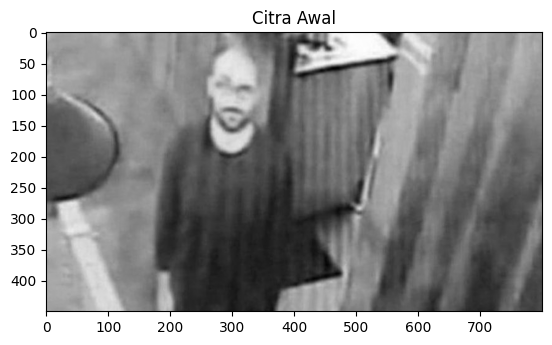

In [9]:
gray1 = Objek1
print(gray1.shape)
plt.title("Citra Awal")
plt.imshow(gray1, cmap='gray')

# Implementasi Konvolusi #
Bagian ini dibuat fungsi convolution() untuk melakukan proses konvolusi antara citra dan kernel.
Hasil konvolusi disimpan dalam matriks baru sebagai citra output.

In [18]:
def convolution(gray1, kernel):

    size = kernel.shape[0]

    pad_size = size // 2

    padded = np.pad(gray1, pad_size, mode='constant')

    canvas = np.zeros_like(gray1).astype(np.float32)

    height, width = gray1.shape

    for i in range(height):

        for j in range(width):
        
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)
    return canvas

# Kernel Smoothing dan Sharpening #

In [19]:
kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5,  1/10],
    [1/10, 1/10, 1/10]
])

kernelSharpening = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
])

# CCTV : Smoothing, Sharpening dan Kombinasi #

Smoothing digunakan untuk menghaluskan citra dan mengurangi noise tapi menyebabkan gambar blur.
Sedangkan, Sharpening digunakan untuk memperjelas detail dan tepi citra tapi memperkuat noise.
Jadi gabungan Smoothing + Sharpening digunakan agar citra jadi lebih seimbang karena noisenya dikurangi dulu sebelum detail nya dipertegas.

Perbedaan antara mean, median, dan modus, adalah mean menghasilkan citra yang halus tetapi cenderung blur, median mengurangi noise tetapi menjaga tepi, sedangkan modus mempertahankan nilai piksel yang paling sering muncul sehingga hasilnya lebih stabil namun tidak sehalus mean.


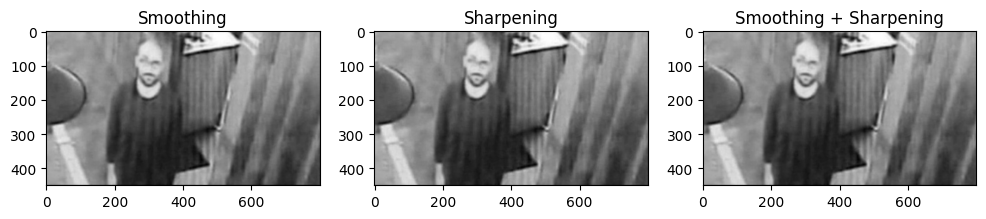

In [24]:
hasil_smoothing = convolution(gray1, kernelSmoothing)
hasil_sharpening = convolution(gray1, kernelSharpening)

Smoothing_Sharpening = convolution(gray1, kernelSmoothing)
Smoothing_Sharpening1 = convolution(Smoothing_Sharpening, kernelSharpening)

plt.figure(figsize=(12,7))

plt.subplot(2,3,1)
plt.imshow(hasil_smoothing, cmap='gray')
plt.title('Smoothing')

plt.subplot(2,3,2)
plt.imshow(hasil_sharpening, cmap='gray')
plt.title('Sharpening')

plt.subplot(2,3,3)
plt.imshow(Smoothing_Sharpening, cmap='gray')
plt.title('Smoothing + Sharpening')

plt.show()

# Kernel Sobel #
Bagian ini didefinisikan kernel Sobel X dan Sobel Y untuk mendeteksi tepi citra.

In [26]:
sobelX = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobelY = np. array([
    [ 1, 2, 1],
    [ 0, 0, 0],
    [-1, -2, -1]
], dtype=np.float32)

# Kernel Prewit #
Bagian ini didefinisikan kernel Prewitt X dan Prewitt Y untuk mendeteksi tepi citra.

In [27]:
prewittX = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

prewittY = np.array([
    [ 1,  1,  1],
    [ 0,  0,  0],
    [-1, -1, -1]
], dtype=np.float32)

# Kernel Roberts #
Bagian ini didefinisikan kernel Roberts X dan Roberts Y untuk mendeteksi tepi citra.

In [28]:
robertsX = np. array([
    [1,  0],
    [0, -1],
], dtype=np. float32)

robertsY = np. array ([
    [0,  1],
    [-1, 0], 
], dtype=np. float32)

# Deteksi Tepi #
Bagian ini dibuat fungsi edge() untuk deteksi tepi menggunakan dua kernel yaitu sumbu x dan y.

In [29]:
def edge(img, kernelx, kernely):
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)
    canvas = np. zeros_like(img, dtype=np. float32)
    canvas = np.abs(gx) + np.abs(gy)
    canvas = canvas * 255.0 / np.max (canvas)
    return np.clip(canvas, 0, 255).astype(np.uint8)

# CCTV: Deteksi Tepi dan Kombinasi Operator #
Operator deteksi tepi seperti Prewitt, Sobel, dan Roberts digunakan untuk menampilkan bagian tepi pada gambar dengan melihat perubahan intensitas piksel. 
Prewitt digunakan untuk deteksi tepi yang sederhana dengan hasil yang cukup jelas
Sobel lebih tegas karena memperhatikan perubahan intensitas
sedangkan Roberts lebih sensitif sehingga bisa menangkap detail kecil tapi mudah terkena noise. 
Jadi, jika operator dikombinasikan dengan cara dijumlahkan, hasilnya bisa menampilkan lebih banyak detail tepi dari berbagai arah.

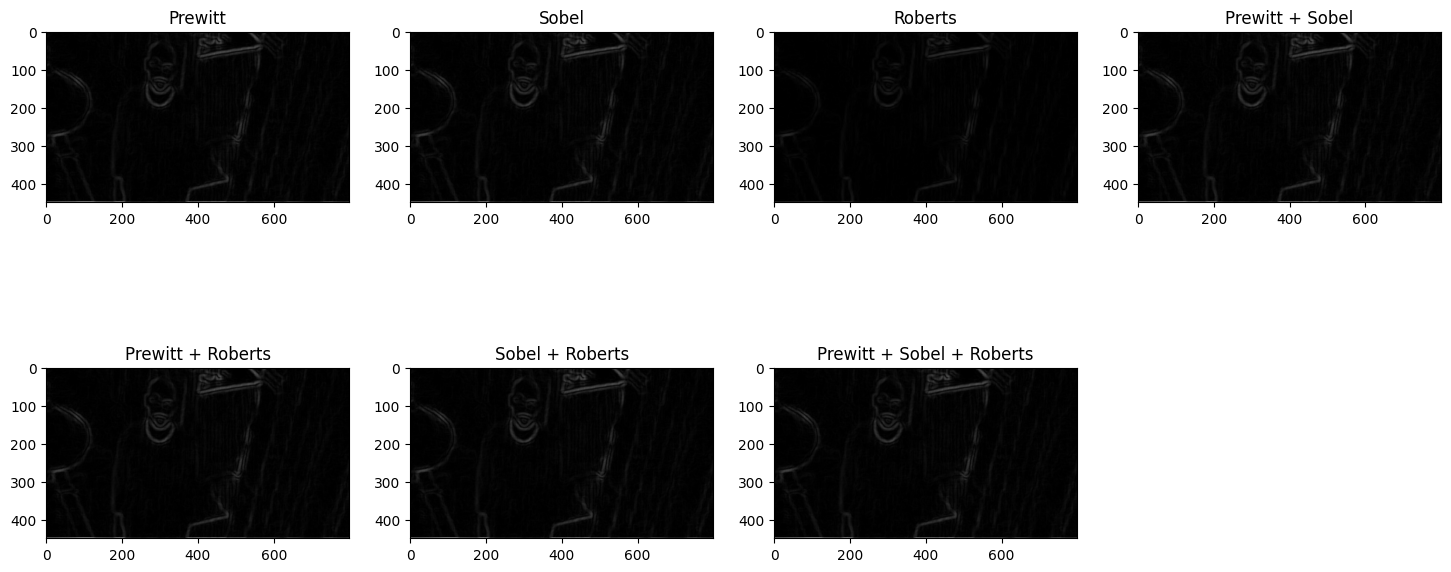

In [36]:
hasil_prewitt = edge(hasil_smoothing, prewittX, prewittY)
hasil_sobel   = edge(hasil_smoothing, sobelX, sobelY)
hasil_roberts = edge(hasil_smoothing, robertsX, robertsY)

PrewittSobel = edge (Smoothing_Sharpening, prewittX, prewittY)
PrewittSobel1 = edge (PrewittSobel, sobelX, sobelY)

PrewittRobert = edge (Smoothing_Sharpening, prewittX, prewittY)
PrewittRobert2 = edge (PrewittRobert, robertsX, robertsY)

SobelRobert = edge (Smoothing_Sharpening, sobelX, sobelY)
SobelRobert3 = edge (SobelRobert, robertsX, robertsY)

PrewittSobelRobert = edge (Smoothing_Sharpening, prewittX, prewittY)
PrewittSobelRobert1 = edge (PrewittSobelRobert, sobelX, sobelY)

plt.figure(figsize=(18,8))

plt.subplot(2,4,1)
plt.imshow(hasil_prewitt, cmap='gray')
plt.title('Prewitt')

plt.subplot(2,4,2)
plt.imshow(hasil_sobel, cmap='gray')
plt.title('Sobel')

plt.subplot(2,4,3)
plt.imshow(hasil_roberts, cmap='gray')
plt.title('Roberts')

plt.subplot(2,4,4)
plt.imshow(PrewittSobel, cmap='gray')
plt.title('Prewitt + Sobel')

plt.subplot(2,4,5)
plt.imshow(PrewittRobert, cmap='gray')
plt.title('Prewitt + Roberts')

plt.subplot(2,4,6)
plt.imshow(SobelRobert, cmap='gray')
plt.title('Sobel + Roberts')

plt.subplot(2,4,7)
plt.imshow(PrewittSobelRobert, cmap='gray')
plt.title('Prewitt + Sobel + Roberts')

plt.show()